(256, 512, 512)
float32


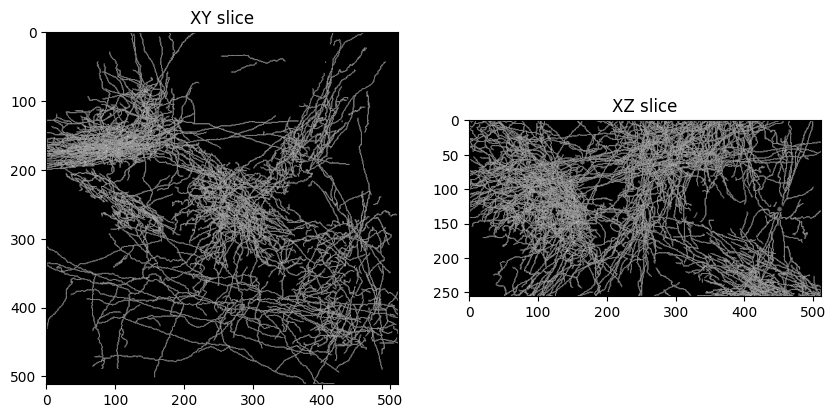

In [1]:
from pathlib import Path
from microsim import schema as ms
from microsim.util import ortho_plot
import numpy as np
from tqdm import tqdm
import math
from tifffile import imread, imwrite

sample = imread("./0001_noScaling.tif")
print(sample.shape)
print(sample.dtype)
sim = ms.Simulation.from_ground_truth(
    ground_truth=sample,
    scale=(0.04, 0.02, 0.02),
    output_space={"downscale": 8},
    modality=ms.Confocal(pinhole_au=1.0),
    detector=ms.CameraCCD(qe=0.82, full_well=18000, read_noise=6, bit_depth=12, offset=100),
    settings=ms.Settings(random_seed=126, max_psf_radius_aus=4)    
)
ground_truth = sim.ground_truth()
ortho_plot(ground_truth, mip=True)

In [2]:
ground_truth.dtype
print(ground_truth.data.min(), ground_truth.data.max())


0.0 6.0


convolving em_psf with pinhole...: 100%|██████████| 256/256 [00:00<00:00, 866.11it/s]


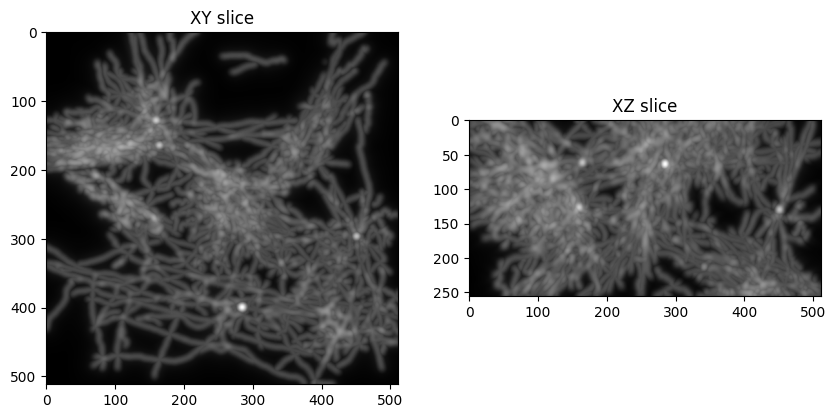

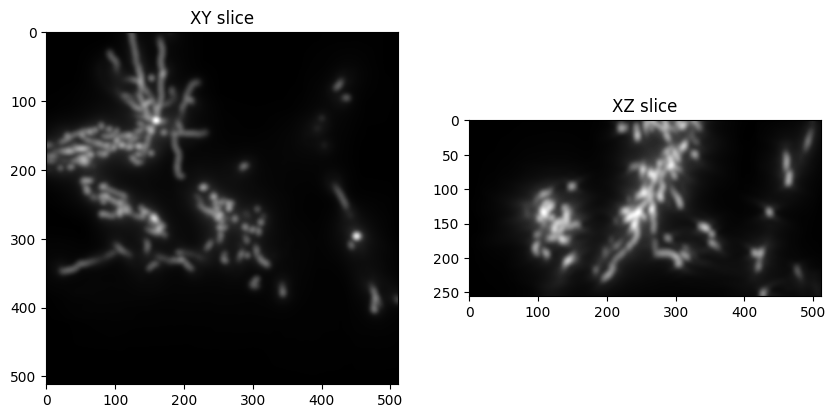

In [3]:
# emission_flux = sim.emission_flux(ground_truth)
optical_img = sim.optical_image(ground_truth)
ortho_plot(optical_img, mip=True)
ortho_plot(optical_img, mip=False)


In [4]:
print(optical_img.shape)

(256, 512, 512)


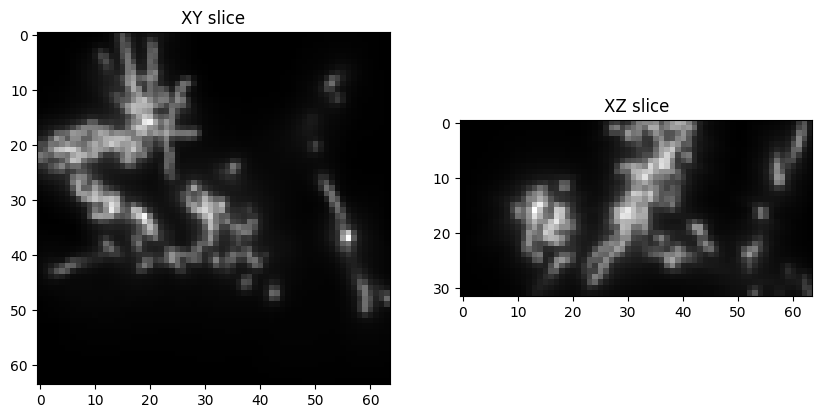

In [5]:
noise_free_digital_image = sim.digital_image(optical_img, with_detector_noise=False)
ortho_plot(noise_free_digital_image, mip=False)
noise_free_digital_image = np.asarray(noise_free_digital_image.data.get())
# imwrite(f"./noise_free/noise_free_digital_image_pin_{sim.modality.pinhole_au}.tif", noise_free_digital_image[16:17, :, :])

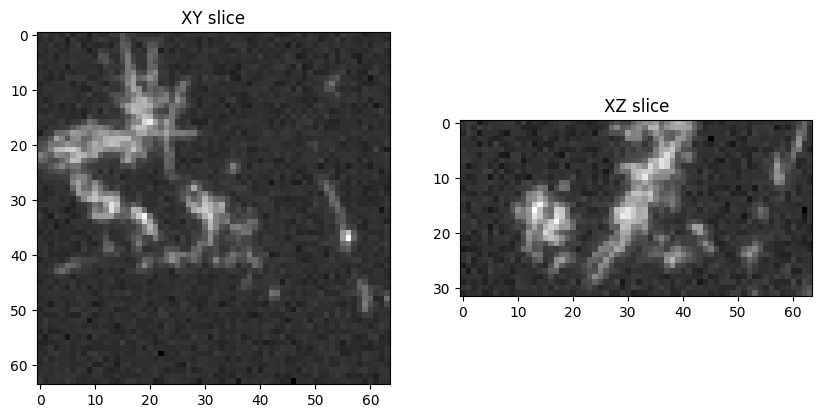

In [6]:
noisy_digital_image = sim.digital_image(optical_img, with_detector_noise=True, photons_pp_ps_max=10000)
ortho_plot(noisy_digital_image, mip=False)
noisy_digital_image = np.asarray(noisy_digital_image.data.get())
# imwrite(f"./noisy/noisy_digital_image_pin_{sim.modality.pinhole_au}.tif", noisy_digital_image[16:17, :, :])